In [1]:
from compress import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ckpt_path = "./4dgs/hpc_outs/output/dnerf/bouncingballs_simple/chkpnt_best.pth"

res = load_original_and_reconstructed(
    ckpt_path=ckpt_path,
    attr_bits=8,
    device="auto",
    compressed_path=None,
    model_overrides={},
    rel_rmse_threshold=1.5e-2,
    max_abs_threshold=3e-2,
)

print("iteration:", res["iteration"])
print("model kwargs:", res["model_kwargs"])
print_validation_report(
    res["validation"],
    rel_rmse_threshold=res["rel_rmse_threshold"],
    max_abs_threshold=res["max_abs_threshold"],
)

iteration: 3500
model kwargs: {'sh_degree': 3, 'gaussian_dim': 4, 'time_duration': [-0.5, 0.5], 'rot_4d': True, 'force_sh_3d': False, 'sh_degree_t': 0, 'prefilter_var': -1.0, 'isotropic_gaussians': False}

validation:
  xyz          MAE=1.099489e-05 RMSE=1.271637e-05 MaxAbs=2.348423e-05 RelMAE=2.079478e-05 RelRMSE=1.911937e-05
  features_dc  MAE=5.901902e-03 RMSE=6.791962e-03 MaxAbs=1.211815e-02 RelMAE=9.460677e-03 RelRMSE=7.286701e-03
  features_rest MAE=2.535255e-04 RMSE=2.945406e-04 MaxAbs=7.588379e-04 RelMAE=1.331070e-02 RelRMSE=8.774577e-03
  scaling      MAE=9.027082e-03 RMSE=1.071066e-02 MaxAbs=2.407861e-02 RelMAE=2.290611e-03 RelRMSE=2.556815e-03
  opacity      MAE=0.000000e+00 RMSE=0.000000e+00 MaxAbs=0.000000e+00 RelMAE=0.000000e+00 RelRMSE=0.000000e+00
  rotation     MAE=1.570944e-03 RMSE=1.839256e-03 MaxAbs=3.871441e-03 RelMAE=5.399350e-03 RelRMSE=3.719224e-03
  t            MAE=6.403144e-03 RMSE=7.393301e-03 MaxAbs=1.279622e-02 RelMAE=1.238847e-02 RelRMSE=1.210658e-02
  sc

In [3]:
ratio_ckpt_disk, pct_ckpt_disk = reduction(res["raw_ckpt_file_size"], res["compressed_disk_size"])
ratio_raw_disk, pct_raw_disk = reduction(res["raw_payload_disk_size"], res["compressed_disk_size"])
ratio_raw_ram, pct_raw_ram = reduction(res["raw_payload_ram_size"], res["compressed_ram_size"])

summary_df = pd.DataFrame([
    {
        "quantity": "raw checkpoint disk",
        "bytes": res["raw_ckpt_file_size"],
        "human": human(res["raw_ckpt_file_size"]),
    },
    {
        "quantity": "raw checkpoint RAM",
        "bytes": res["raw_ckpt_ram_size"],
        "human": human(res["raw_ckpt_ram_size"]),
    },
    {
        "quantity": "raw gaussian disk",
        "bytes": res["raw_payload_disk_size"],
        "human": human(res["raw_payload_disk_size"]),
    },
    {
        "quantity": "raw gaussian RAM",
        "bytes": res["raw_payload_ram_size"],
        "human": human(res["raw_payload_ram_size"]),
    },
    {
        "quantity": "compressed disk",
        "bytes": res["compressed_disk_size"],
        "human": human(res["compressed_disk_size"]),
    },
    {
        "quantity": "compressed RAM",
        "bytes": res["compressed_ram_size"],
        "human": human(res["compressed_ram_size"]),
    },
])

metrics_df = pd.DataFrame([
    {
        "comparison": "vs raw checkpoint disk",
        "ratio_smaller": ratio_ckpt_disk,
        "reduction_pct": pct_ckpt_disk,
    },
    {
        "comparison": "vs raw gaussian disk",
        "ratio_smaller": ratio_raw_disk,
        "reduction_pct": pct_raw_disk,
    },
    {
        "comparison": "vs raw gaussian RAM",
        "ratio_smaller": ratio_raw_ram,
        "reduction_pct": pct_raw_ram,
    },
])

display(summary_df)
display(metrics_df)

,quantity,bytes,human
0,raw checkpoint disk,192389960,183.48 MiB
1,raw checkpoint RAM,192365712,183.45 MiB
2,raw gaussian disk,63535625,60.59 MiB
3,raw gaussian RAM,63531888,60.59 MiB
4,compressed disk,21932133,20.92 MiB
5,compressed RAM,14324580,13.66 MiB


,comparison,ratio_smaller,reduction_pct
0,vs raw checkpoint disk,8.772059,88.600168
1,vs raw gaussian disk,2.896920,65.480574
2,vs raw gaussian RAM,4.435166,77.452929


In [4]:
per_tensor_df = pd.DataFrame(res["validation"]["per_tensor"]).T
per_tensor_df = per_tensor_df.sort_values("rel_rmse", ascending=False)
display(per_tensor_df)

,mae,rmse,max_abs,rel_mae,rel_rmse
t,0.006403,0.007393,0.012796,0.012388,0.012107
features_rest,0.000254,0.000295,0.000759,0.013311,0.008775
features_dc,0.005902,0.006792,0.012118,0.009461,0.007287
scaling_t,0.008220,0.009496,0.016451,0.004853,0.004404
rotation_r,0.001642,0.001938,0.004422,0.005619,0.003850
rotation,0.001571,0.001839,0.003871,0.005399,0.003719
scaling,0.009027,0.010711,0.024079,0.002291,0.002557
xyz,0.000011,0.000013,0.000023,0.000021,0.000019
opacity,0.000000,0.000000,0.000000,0.000000,0.000000


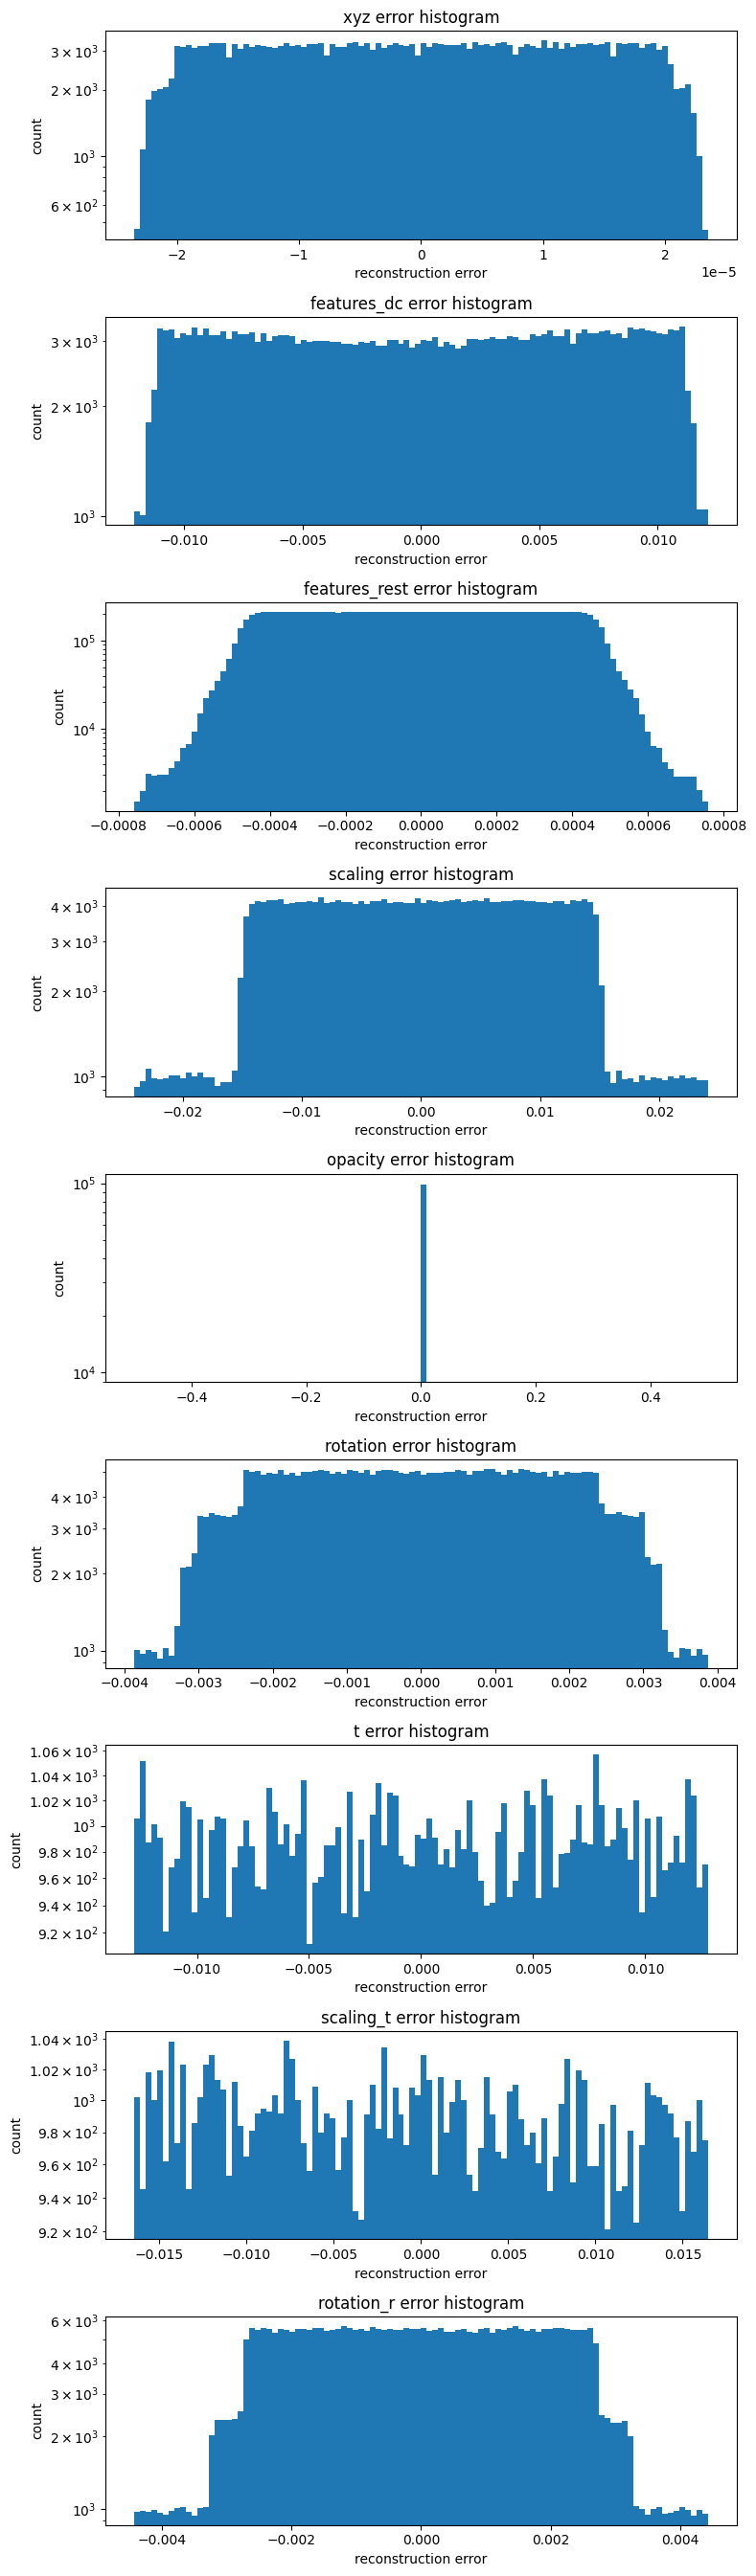

In [5]:
def flatten_error(orig, recon):
    return (orig.float() - recon.float()).reshape(-1).cpu().numpy()

fig, axes = plt.subplots(len(res["orig_tensors"]), 1, figsize=(8, 3 * len(res["orig_tensors"])))
if len(res["orig_tensors"]) == 1:
    axes = [axes]

for ax, name in zip(axes, res["orig_tensors"].keys()):
    err = flatten_error(res["orig_tensors"][name], res["recon_tensors"][name])
    ax.hist(err, bins=100, log=True)
    ax.set_title(f"{name} error histogram")
    ax.set_xlabel("reconstruction error")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

xyz mean L2 error: 2.1148833e-05
xyz median L2 error: 2.1668367e-05
xyz max L2 error: 3.788841e-05


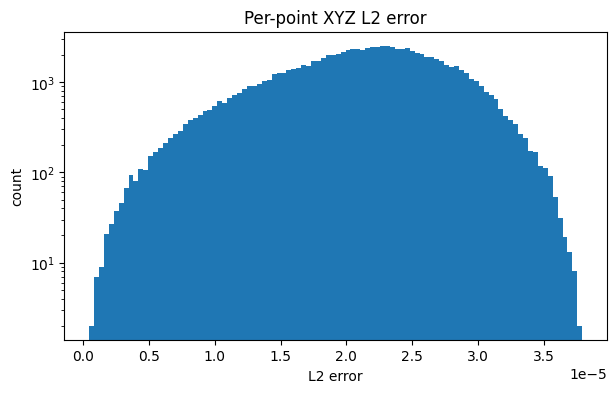

In [6]:
orig_xyz = res["orig_tensors"]["xyz"]
recon_xyz = res["recon_tensors"]["xyz"]

xyz_err = torch.norm(orig_xyz.float() - recon_xyz.float(), dim=1).cpu().numpy()

print("xyz mean L2 error:", xyz_err.mean())
print("xyz median L2 error:", np.median(xyz_err))
print("xyz max L2 error:", xyz_err.max())

plt.figure(figsize=(7, 4))
plt.hist(xyz_err, bins=100, log=True)
plt.title("Per-point XYZ L2 error")
plt.xlabel("L2 error")
plt.ylabel("count")
plt.show()

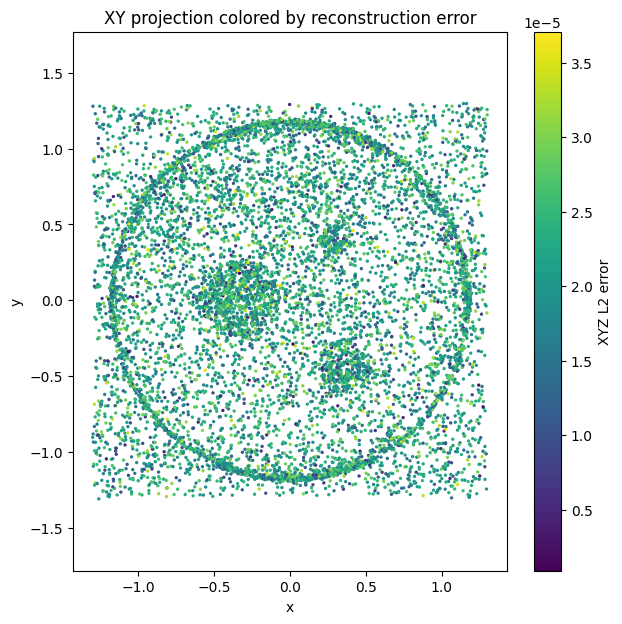

In [7]:
# 2D projection of a random subset, colored by XYZ error
rng = np.random.default_rng(0)
n = min(10000, orig_xyz.shape[0])
idx = rng.choice(orig_xyz.shape[0], size=n, replace=False)

pts = orig_xyz[idx].cpu().numpy()
err = xyz_err[idx]

plt.figure(figsize=(7, 7))
sc = plt.scatter(pts[:, 0], pts[:, 1], c=err, s=2)
plt.colorbar(sc, label="XYZ L2 error")
plt.title("XY projection colored by reconstruction error")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

In [8]:
# Worst reconstructed points
k = 20
worst_idx = np.argsort(-xyz_err)[:k]

worst_df = pd.DataFrame({
    "idx": worst_idx,
    "xyz_err_l2": xyz_err[worst_idx],
    "orig_x": orig_xyz[worst_idx, 0].cpu().numpy(),
    "orig_y": orig_xyz[worst_idx, 1].cpu().numpy(),
    "orig_z": orig_xyz[worst_idx, 2].cpu().numpy(),
    "recon_x": recon_xyz[worst_idx, 0].cpu().numpy(),
    "recon_y": recon_xyz[worst_idx, 1].cpu().numpy(),
    "recon_z": recon_xyz[worst_idx, 2].cpu().numpy(),
})
display(worst_df)

,idx,xyz_err_l2,orig_x,orig_y,orig_z,recon_x,recon_y,recon_z
0,23454,0.000038,0.667459,-0.328059,-0.050034,0.667437,-0.328080,-0.050057
1,91665,0.000038,-0.326820,-0.145386,0.953215,-0.326841,-0.145406,0.953192
2,79538,0.000037,-0.627706,1.064796,0.508062,-0.627728,1.064775,0.508084
3,71374,0.000037,-0.632410,-0.419031,0.291900,-0.632432,-0.419051,0.291923
4,90085,0.000037,-1.193994,1.219178,0.889934,-1.193974,1.219158,0.889958
5,26394,0.000037,-1.102063,-0.333871,-0.012977,-1.102041,-0.333852,-0.012999
6,26932,0.000037,-0.008504,1.175603,-0.011022,-0.008482,1.175583,-0.011000
7,63712,0.000037,0.077111,0.035905,0.059232,0.077133,0.035885,0.059209
8,39192,0.000037,-0.049946,1.173895,0.003437,-0.049924,1.173876,0.003414
9,28226,0.000037,-1.165995,0.203864,-0.007956,-1.166017,0.203844,-0.007978


In [9]:
# Attribute-specific absolute error summaries
rows = []
for name in res["orig_tensors"].keys():
    o = res["orig_tensors"][name].float()
    r = res["recon_tensors"][name].float()
    e = (o - r).abs()

    rows.append({
        "tensor": name,
        "mean_abs": e.mean().item(),
        "median_abs": e.median().item(),
        "p95_abs": torch.quantile(e.reshape(-1), 0.95).item(),
        "p99_abs": torch.quantile(e.reshape(-1), 0.99).item(),
        "max_abs": e.max().item(),
    })

attr_err_df = pd.DataFrame(rows).sort_values("p95_abs", ascending=False)
display(attr_err_df)

,tensor,mean_abs,median_abs,p95_abs,p99_abs,max_abs
3,scaling,0.009027,0.008588,0.020471,0.023321,0.024079
7,scaling_t,0.008220,0.008223,0.015630,0.016290,0.016451
6,t,0.006403,0.006412,0.012162,0.012675,0.012796
1,features_dc,0.005902,0.005948,0.011050,0.011776,0.012118
8,rotation_r,0.001642,0.001579,0.003538,0.004244,0.004422
5,rotation,0.001571,0.001522,0.003189,0.003717,0.003871
2,features_rest,0.000254,0.000251,0.000485,0.000569,0.000759
0,xyz,0.000011,0.000011,0.000021,0.000023,0.000023
4,opacity,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
# Compression-quality sweep over several bitrates
def evaluate_attr_bits(ckpt_path, bits_list=(4, 6, 8, 10, 12), device="cpu"):
    rows = []

    for bits in bits_list:
        res_i = load_original_and_reconstructed(
            ckpt_path=ckpt_path,
            attr_bits=bits,
            device=device,
            compressed_path=None,
        )

        ratio_disk, pct_disk = reduction(res_i["raw_payload_disk_size"], res_i["compressed_disk_size"])
        ratio_ram, pct_ram = reduction(res_i["raw_payload_ram_size"], res_i["compressed_ram_size"])

        rows.append({
            "attr_bits": bits,
            "compressed_disk_bytes": res_i["compressed_disk_size"],
            "compressed_ram_bytes": res_i["compressed_ram_size"],
            "disk_ratio_smaller": ratio_disk,
            "disk_reduction_pct": pct_disk,
            "ram_ratio_smaller": ratio_ram,
            "ram_reduction_pct": pct_ram,
            "worst_rel_rmse": res_i["validation"]["worst_rel_rmse"],
            "worst_max_abs": res_i["validation"]["worst_max_abs"],
        })

    return pd.DataFrame(rows)

sweep_df = evaluate_attr_bits(ckpt_path, bits_list=(4, 6, 8, 10, 12), device="cpu")
display(sweep_df)

,attr_bits,compressed_disk_bytes,compressed_ram_bytes,disk_ratio_smaller,disk_reduction_pct,ram_ratio_smaller,ram_reduction_pct,worst_rel_rmse,worst_max_abs
0,4,11068837,7138127,5.740045,82.578534,8.900358,88.764497,0.209879,0.409337
1,6,16242597,10574397,3.911667,74.435449,6.008086,83.355765,0.049134,0.097461
2,8,21935077,14324580,2.896531,65.475940,4.435166,77.452929,0.012107,0.024079
3,10,27991013,18190274,2.269858,55.944381,3.492630,71.368277,0.003020,0.006003
4,12,34743013,22061049,1.828731,45.317272,2.879822,65.275628,0.000752,0.001501


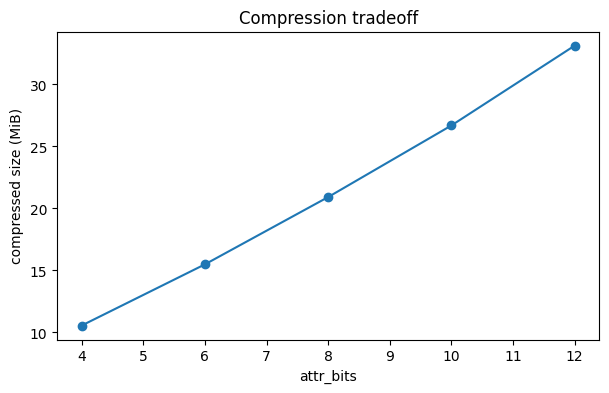

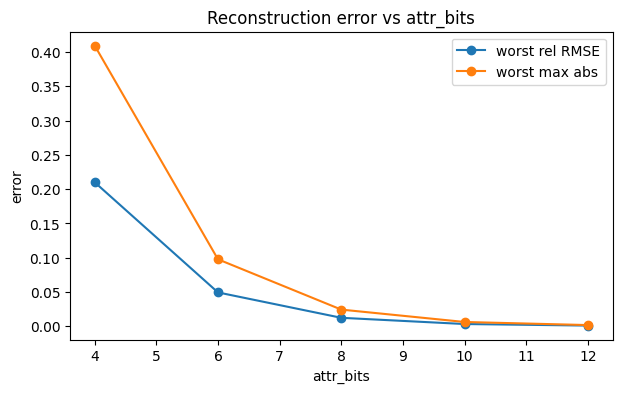

In [11]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sweep_df["attr_bits"], sweep_df["compressed_disk_bytes"] / (1024 ** 2), marker="o")
ax1.set_xlabel("attr_bits")
ax1.set_ylabel("compressed size (MiB)")
ax1.set_title("Compression tradeoff")

plt.show()

fig, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(sweep_df["attr_bits"], sweep_df["worst_rel_rmse"], marker="o", label="worst rel RMSE")
ax2.plot(sweep_df["attr_bits"], sweep_df["worst_max_abs"], marker="o", label="worst max abs")
ax2.set_xlabel("attr_bits")
ax2.set_ylabel("error")
ax2.set_title("Reconstruction error vs attr_bits")
ax2.legend()
plt.show()

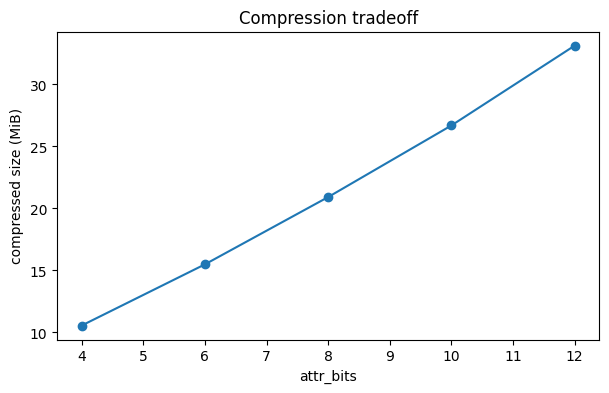

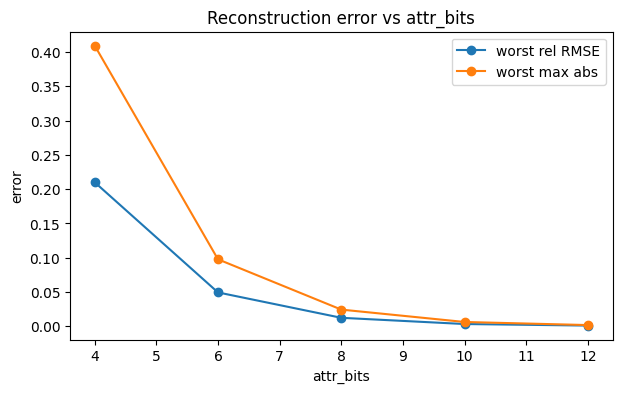

In [12]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sweep_df["attr_bits"], sweep_df["compressed_disk_bytes"] / (1024 ** 2), marker="o")
ax1.set_xlabel("attr_bits")
ax1.set_ylabel("compressed size (MiB)")
ax1.set_title("Compression tradeoff")

plt.show()

fig, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(sweep_df["attr_bits"], sweep_df["worst_rel_rmse"], marker="o", label="worst rel RMSE")
ax2.plot(sweep_df["attr_bits"], sweep_df["worst_max_abs"], marker="o", label="worst max abs")
ax2.set_xlabel("attr_bits")
ax2.set_ylabel("error")
ax2.set_title("Reconstruction error vs attr_bits")
ax2.legend()
plt.show()